# 02 — Attention Map 可視化

学習済みモデルの **Attention weight** を hook で取り出して可視化する。

- **ヘッド別マップ**: 各ヘッドが何に注目しているか
- **CLS アテンション**: 分類に使われる CLS トークンがどこを見ているか
- **Attention Rollout**: 全層を合成して「最終的にどこを見た」かを 1 枚で表す


モデルロード完了  パラメータ数: 3,190,634


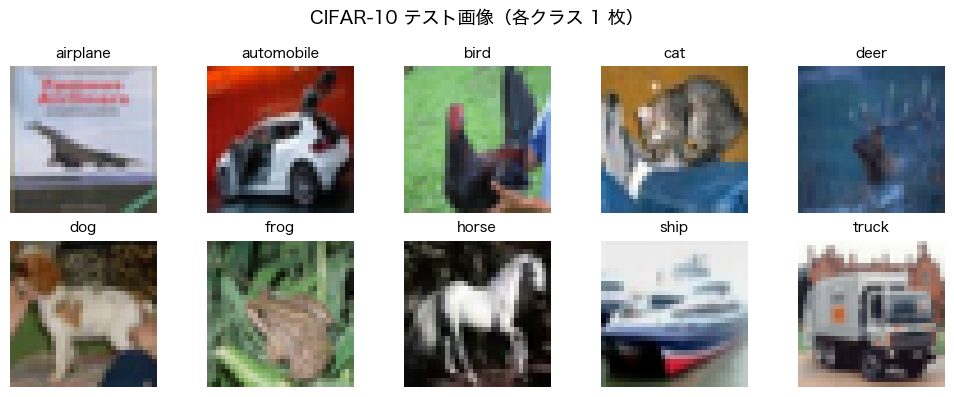

In [1]:
import sys, pathlib
# notebooks/ の親（vit/）を Python パスに追加して vit パッケージを import できるようにする
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib
import matplotlib.font_manager as _fm
# macOS 標準の日本語フォントを自動検出して設定（なければ DejaVu にフォールバック）
_jp = next((f.name for f in _fm.fontManager.ttflist if "Hiragino Sans" == f.name), None)
if _jp:
    matplotlib.rcParams["font.family"] = _jp
matplotlib.rcParams["axes.unicode_minus"] = False  # マイナス記号の文字化け防止

import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
from viz_utils import (
    CIFAR10_CLASSES, CIFAR10_MEAN, CIFAR10_STD,
    denormalize, to_hwc, show_image, show_patches,
    overlay_attention, attention_rollout,
)
from vit import ViT

MODEL_PATH  = "../best_vit.pth"
DATA_ROOT   = "../data"
PATCH_SIZE  = 4
EMBED_DIM   = 256
DEPTH       = 6
NUM_HEADS   = 8
MLP_DIM     = 512
model = ViT(
    image_size=32, patch_size=PATCH_SIZE, num_classes=10,
    embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM, dropout=0.1, emb_dropout=0.1,
)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
print(f"モデルロード完了  パラメータ数: {model.num_parameters():,}")
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_ds = torchvision.datasets.CIFAR10(
    root=DATA_ROOT, train=False, download=False, transform=transform
)

# クラスごとに 1 枚ずつ集める
by_class: dict[int, torch.Tensor] = {}
for img, label in test_ds:
    if label not in by_class:
        by_class[label] = img
    if len(by_class) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for cls_id, ax in zip(range(10), axes.flat):
    show_image(by_class[cls_id], ax=ax, title=CIFAR10_CLASSES[cls_id])
fig.suptitle("CIFAR-10 テスト画像（各クラス 1 枚）", fontsize=13)
plt.tight_layout()
plt.show()


## Hook でアテンション重みを取り出す

`block.attn.attn_drop` は softmax 直後の Dropout モジュール。
ここへの **forward hook** で `(B, H, N, N)` のアテンション重みをキャプチャできる。


In [2]:
attn_store: dict[str, torch.Tensor] = {}

def make_hook(key: str):
    def hook(module, input, output):
        # input[0] = softmax 後のアテンション重み (B, H, N, N)
        attn_store[key] = input[0].detach().cpu()
    return hook

handles = []
for i, block in enumerate(model.transformer):
    h = block.attn.attn_drop.register_forward_hook(make_hook(f"layer_{i}"))
    handles.append(h)

print(f"{len(handles)} 個の hook を登録しました")
print("キャプチャされるキー:", [f"layer_{i}" for i in range(len(handles))])


6 個の hook を登録しました
キャプチャされるキー: ['layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5']


## 推論の実行

画像を 1 枚選んで forward を走らせる。
hook が発火してアテンション重みが `attn_store` に保存される。


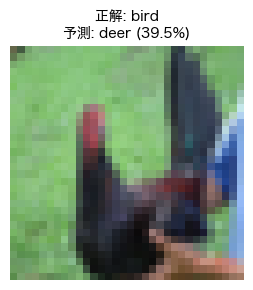

  layer_0: (1, 8, 65, 65)  (B, H, N, N)
  layer_1: (1, 8, 65, 65)  (B, H, N, N)
  layer_2: (1, 8, 65, 65)  (B, H, N, N)
  layer_3: (1, 8, 65, 65)  (B, H, N, N)
  layer_4: (1, 8, 65, 65)  (B, H, N, N)
  layer_5: (1, 8, 65, 65)  (B, H, N, N)


In [3]:
# 「bird」で試す
TARGET_CLASS = 2   # bird
img = by_class[TARGET_CLASS]

with torch.no_grad():
    logits = model(img.unsqueeze(0))     # forward → hook が発火
    probs  = torch.softmax(logits[0], dim=-1)

pred = probs.argmax().item()

fig, ax = plt.subplots(figsize=(3, 3))
show_image(img, ax=ax,
           title=f"正解: {CIFAR10_CLASSES[TARGET_CLASS]}\n"
                 f"予測: {CIFAR10_CLASSES[pred]} ({probs[pred]*100:.1f}%)")
plt.tight_layout()
plt.show()

# attn_store の内容確認
for k, v in attn_store.items():
    print(f"  {k}: {tuple(v.shape)}  (B, H, N, N)")


## ヘッド別アテンションマップ（最終層）

最終層（layer_5）の 8 ヘッドそれぞれが「どのトークンからどのトークンへ注目しているか」を表示する。
行 = query トークン、列 = key トークン。明るいほど注目度が高い。


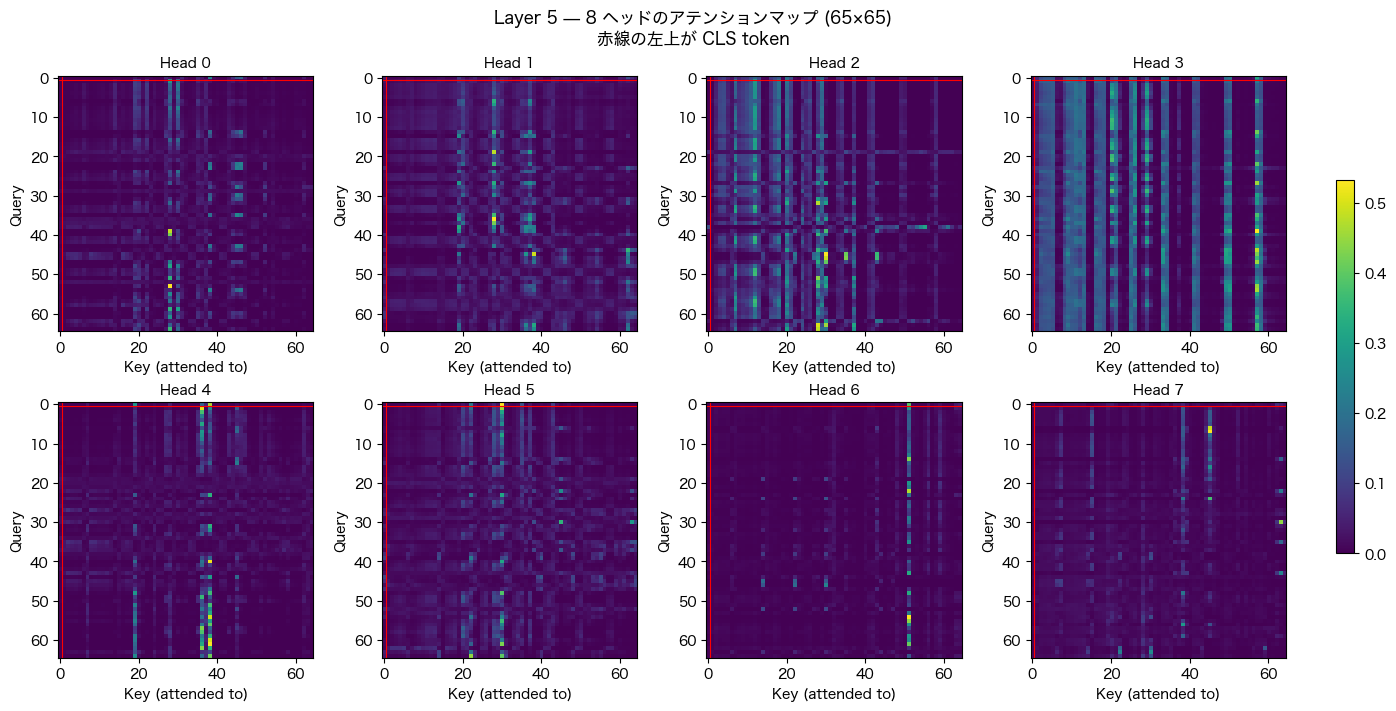

In [4]:
LAYER = DEPTH - 1  # 最終層
attn = attn_store[f"layer_{LAYER}"][0]  # (H, 65, 65) ← バッチ次元を除去

fig, axes = plt.subplots(2, 4, figsize=(14, 7), constrained_layout=True)
for h, ax in enumerate(axes.flat):
    im = ax.imshow(attn[h].numpy(), cmap="viridis", vmin=0)
    ax.set_title(f"Head {h}", fontsize=10)
    ax.set_xlabel("Key (attended to)")
    ax.set_ylabel("Query")
    # CLS トークンの境界線
    ax.axhline(0.5, color="red", lw=0.8)
    ax.axvline(0.5, color="red", lw=0.8)

fig.suptitle(f"Layer {LAYER} — 8 ヘッドのアテンションマップ (65×65)\n"
             f"赤線の左上が CLS token", fontsize=12)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.04)
plt.show()


## CLS → パッチ アテンション（全層）

`attn[h, 0, 1:]` = CLS トークン（index=0）が各パッチ（index=1–64）へ払うアテンション。
これを 8×8 グリッドにリシェイプして元画像に重ね合わせる。
**層が深まるにつれて注目が特定の領域に絞られていく**様子が見える。


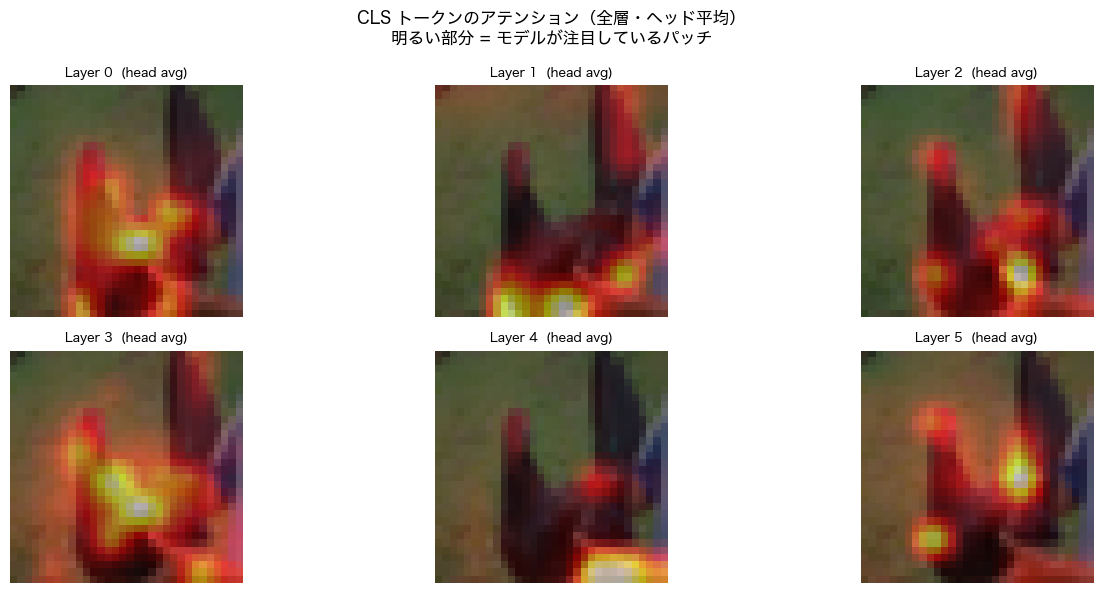

In [5]:
fig, axes = plt.subplots(2, DEPTH // 2, figsize=(14, 6))
axes = axes.flat

for layer_idx in range(DEPTH):
    attn = attn_store[f"layer_{layer_idx}"][0]  # (H, 65, 65)
    # ヘッド平均の CLS → パッチ アテンション
    cls_attn = attn.mean(dim=0)[0, 1:]          # (64,)

    overlay_attention(img, cls_attn, ax=axes[layer_idx],
                      title=f"Layer {layer_idx}  (head avg)")

fig.suptitle("CLS トークンのアテンション（全層・ヘッド平均）\n"
             "明るい部分 = モデルが注目しているパッチ",
             fontsize=12)
plt.tight_layout()
plt.show()


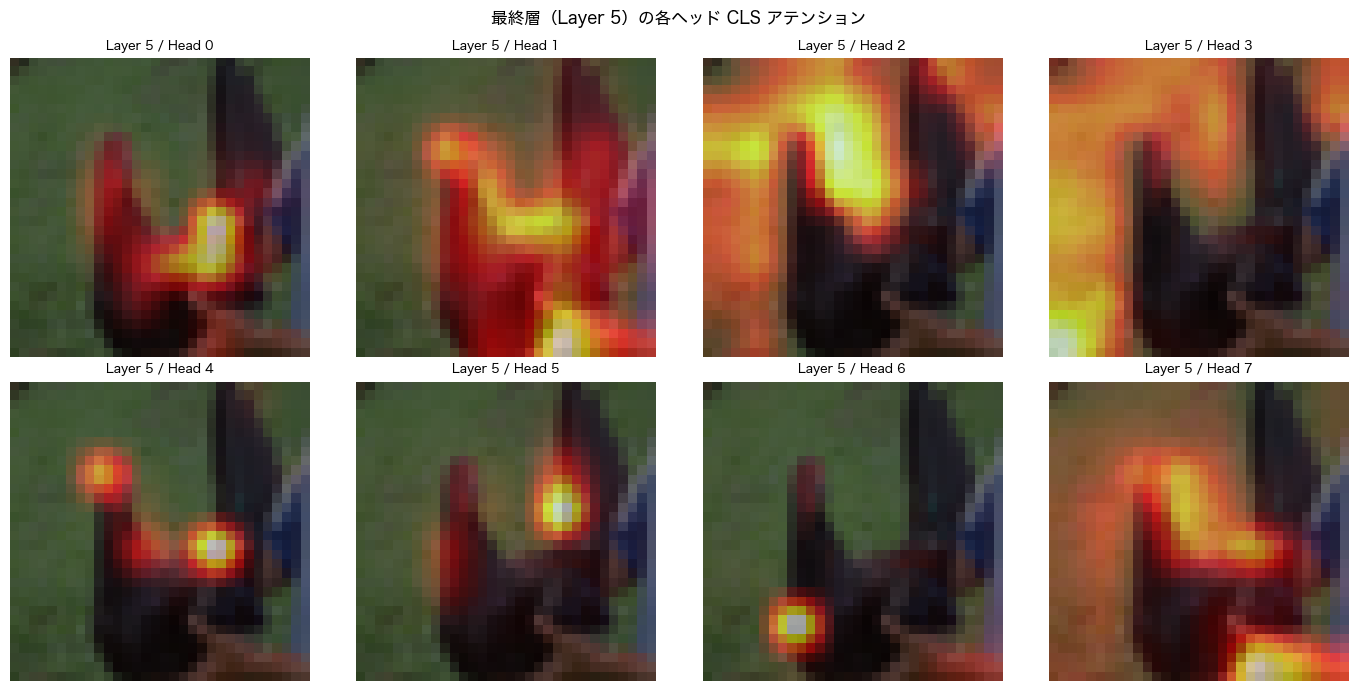

In [6]:
# 最終層は各ヘッド個別にも表示
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
attn_last = attn_store[f"layer_{DEPTH-1}"][0]  # (H, 65, 65)

for h, ax in enumerate(axes.flat):
    cls_attn = attn_last[h, 0, 1:]   # (64,)
    overlay_attention(img, cls_attn, ax=ax, title=f"Layer {DEPTH-1} / Head {h}")

fig.suptitle(f"最終層（Layer {DEPTH-1}）の各ヘッド CLS アテンション", fontsize=12)
plt.tight_layout()
plt.show()


## Attention Rollout

全 6 層のアテンションを**積算合成**して「入力パッチから最終的に CLS トークンへ
どれだけ情報が流れたか」を 1 枚のマップで表す。
単層の CLS アテンションより安定した可視化が得られる。

> Abnar & Zuidema (2020) "Quantifying Attention Flow in Transformers"


Rollout の形状: (64,)
最大注意パッチ index: 43  (8×8 grid 上: row=5, col=3)


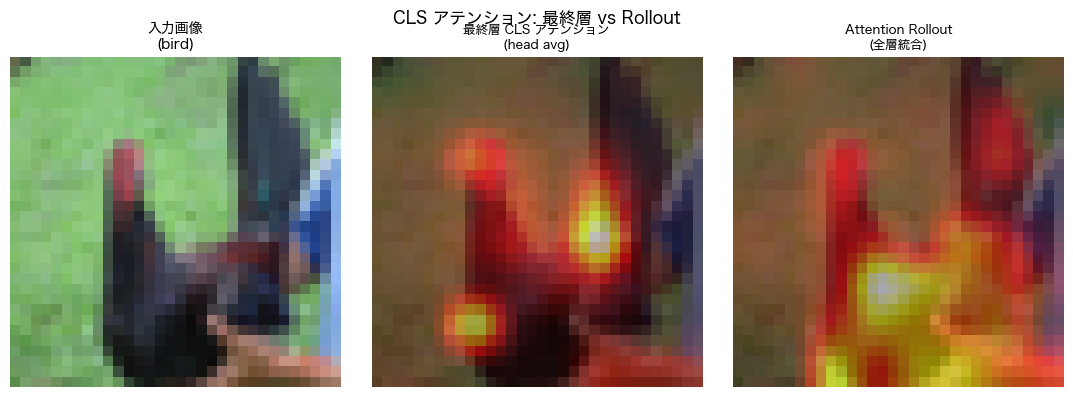

In [7]:
# 全層のアテンション（ヘッド次元あり）をリストにまとめる
attn_per_layer = [
    attn_store[f"layer_{i}"][0]  # (H, 65, 65)
    for i in range(DEPTH)
]

rollout = attention_rollout(attn_per_layer)  # (64,)
print(f"Rollout の形状: {tuple(rollout.shape)}")
print(f"最大注意パッチ index: {rollout.argmax().item()}  "
      f"(8×8 grid 上: row={rollout.argmax().item()//8}, col={rollout.argmax().item()%8})")

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

show_image(img, ax=axes[0], title=f"入力画像\n({CIFAR10_CLASSES[TARGET_CLASS]})")

# 最終層のヘッド平均 CLS アテンション
cls_last = attn_store[f"layer_{DEPTH-1}"][0].mean(0)[0, 1:]
overlay_attention(img, cls_last, ax=axes[1],
                  title=f"最終層 CLS アテンション\n(head avg)")

# Rollout
overlay_attention(img, rollout, ax=axes[2],
                  title="Attention Rollout\n(全層統合)")

fig.suptitle("CLS アテンション: 最終層 vs Rollout", fontsize=12)
plt.tight_layout()
plt.show()


In [8]:
# hook を解除
for h in handles:
    h.remove()
print("hook を解除しました")


hook を解除しました
